In [1]:
# Imports
from data_management.data_manager import data_manager

Loading dataset from dataset_config:
DatasetConfig(
	raw_data_source_type=local
	raw_data_dir=C:\TESS\data\lc\Vetting
	reports_dir=C:\TESS\data\reports
	images_dir=C:\TESS\data\images
	labels_sheet=https://docs.google.com/spreadsheets/d/17-ByYBQ1uPweKH2P_4MWGWsuTKkEKrNFS4uGBsm-bGI/edit?gid=0#gid=0
	properties_sheet=https://docs.google.com/spreadsheets/d/1x7MqQK6mEedUrsKO8Z7T0x_APT-6S1ik6UMvAYx4ZFg/edit?gid=302748837#gid=302748837
	dataset_split_sheet=https://docs.google.com/spreadsheets/d/1w_YvlGCQpdlPPC7JJgAUDANU2JU0cC9P-gwMeoYvMw8/edit?gid=0#gid=0
)



c:\tessgit\astronet\data_management\google_sheets_reader.py:59: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(["#N/A", "", "N/A"], np.nan, inplace=True)


(9605, 24)
AstroDataReport:
  - # Successful Load: 9605
  - FITS Files Failed to Load: 7188
  - Labels Failed to Load: 0
  - Properties Failed to Load: 0



In [2]:
# show properties in the data frame
df = data_manager.get_data_frame()
print(df.head())

   astro_id     tic_id fits_path  \
0         1  101179364      <NA>   
1         2  101255974      <NA>   
2         3  101404344      <NA>   
3         4  101427335      <NA>   
4         5   10150705      <NA>   

                                        report_paths   label  \
0  ['C:\\TESS\\data\\reports\\101179364.page1.png...  disp_e   
1  ['C:\\TESS\\data\\reports\\101255974.page1.png...  disp_e   
2  ['C:\\TESS\\data\\reports\\101404344.page1.png...  disp_e   
3  ['C:\\TESS\\data\\reports\\101427335.page1.png...  disp_e   
4  ['C:\\TESS\\data\\reports\\10150705.page1.png'...  disp_e   

   label_simplified        split final decision distinct  ... sectors  \
0  Eclipsing Binary  unallocated    et     <NA>      1.0  ...    <NA>   
1  Eclipsing Binary  unallocated    eb       eb      2.0  ...    <NA>   
2  Eclipsing Binary  unallocated    eb       eb      2.0  ...    <NA>   
3  Eclipsing Binary  unallocated    et       et      2.0  ...    <NA>   
4  Eclipsing Binary  unallocated 

In [11]:
# Show labels for a specific TIC ID
# grab a TIC id at random from the df where the label is not NaN
tic_id = df.loc[df['label'].notna(), 'tic_id'].sample(1).values[0]
print(f"Showing labels for TIC ID: {tic_id}")
# show simplified label and label
df_labels = df.loc[df['tic_id'] == tic_id, ['tic_id', 'label', 'label_simplified']]
print(df_labels)
# print the raw data path and report path for the TIC ID
df_raw_path = df.loc[df['tic_id'] == tic_id, 'fits_path'].values[0]
df_report_path = df.loc[df['tic_id'] == tic_id, 'report_paths'].values[0]
print(f"Raw data path: {df_raw_path}")
print(f"Report path: {df_report_path}")

Showing labels for TIC ID: 19686666
      tic_id label  label_simplified
98  19686666    eu  Eclipsing Binary
Raw data path: C:\TESS\data\lc\Vetting\mk_hlsp_qlp_tess_ffi-s0007-0000000019686666_tess_v01_llc.fits
Report path: ['C:\\TESS\\data\\reports\\19686666.page1.png', 'C:\\TESS\\data\\reports\\19686666.page2.png', 'C:\\TESS\\data\\reports\\19686666.page3.png']


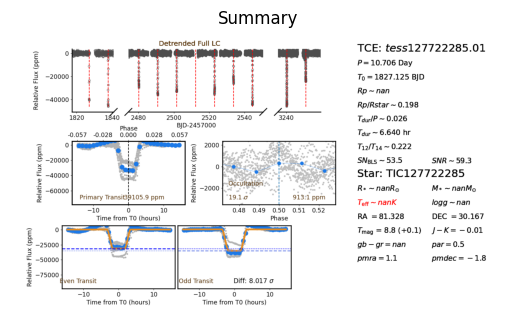

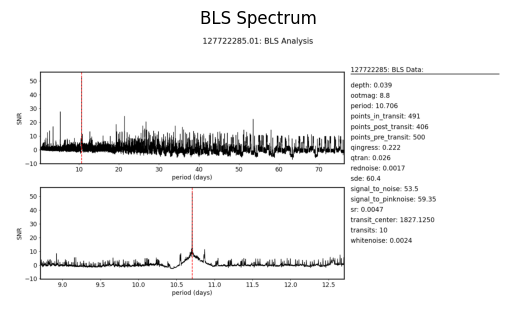

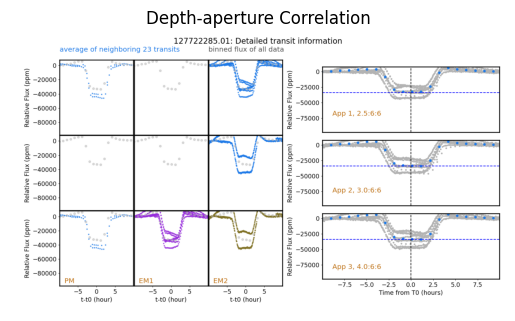

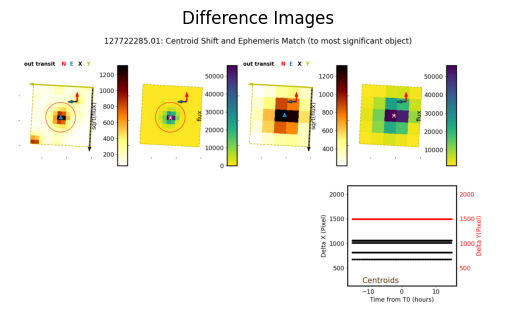

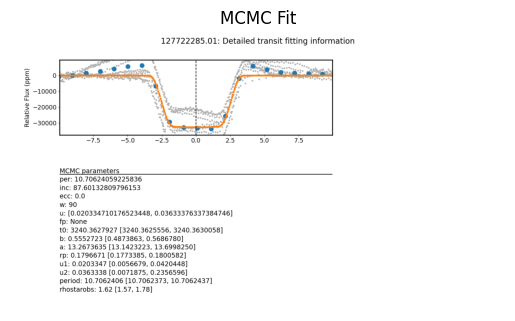

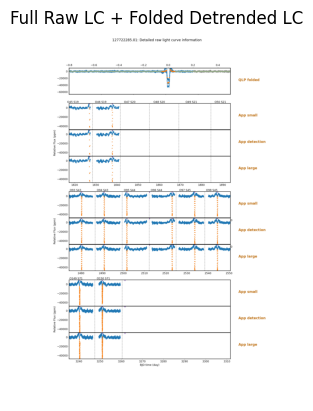

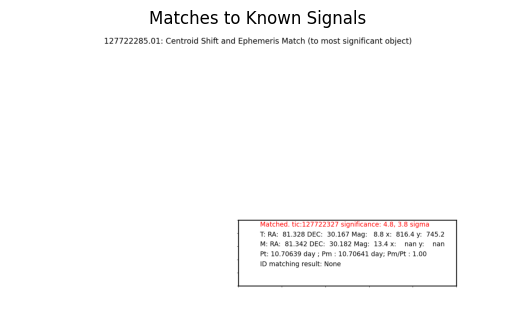

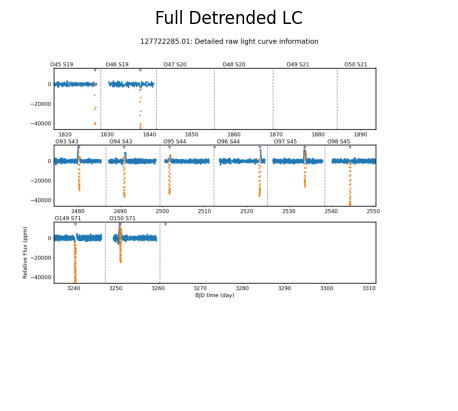

<Figure size 640x480 with 0 Axes>

In [1]:
# Locate reports
from data_management.light_curve_server import LightCurveServer, PAGE_NUMBER_TO_TYPE
import matplotlib.pyplot as plt
from IPython.display import display


server = LightCurveServer()
pages = server.get_report_pages(127722285)
for page in pages:
    im = server.get_page_image(tic_id=127722285, page_number=page)
    plt.title(PAGE_NUMBER_TO_TYPE[page])
    plt.axis('off')
    plt.imshow(im)
    display(plt.gcf())
    plt.clf()
